# Phase 4: Generation and Evaluation
## SVG Scaling Laws - CS-GY 6923

**Steps:**
1. Mount Drive & clone/pull repo
2. Install dependencies (incl. cairosvg system libs)
3. Symlink `outputs/` to Drive
4. Verify the SP XL checkpoint and the tokenizer are present
5. Generate samples (script 10)
6. Evaluate samples + test perplexity (script 11)
7. Plot sample figures (script 12)
8. Display the metrics table inline

---
## Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_DIR = '/content/drive/MyDrive/svg-scaling-laws'
os.makedirs(DRIVE_DIR, exist_ok=True)
print(f'Drive mounted. Project dir: {DRIVE_DIR}')

Mounted at /content/drive
Drive mounted. Project dir: /content/drive/MyDrive/svg-scaling-laws


---
## Clone / Pull Repository

In [3]:
REPO_URL = 'https://github.com/taahamohsin/ml-extra-credit-project'
REPO_DIR = '/content/svg-scaling-laws'

import os
if os.path.exists(REPO_DIR):
    print('Repo already exists, pulling latest ...')
    !cd {REPO_DIR} && git pull
else:
    print('Cloning repo ...')
    !git clone {REPO_URL} {REPO_DIR}

%cd {REPO_DIR}
print(f'Working directory: {os.getcwd()}')

Cloning repo ...
Cloning into '/content/svg-scaling-laws'...
remote: Enumerating objects: 365, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 365 (delta 30), reused 35 (delta 17), pack-reused 296 (from 1)
Receiving objects: 100% (365/365), 2.95 MiB | 7.31 MiB/s, done.
Resolving deltas: 100% (225/225), done.
/content/svg-scaling-laws
Working directory: /content/svg-scaling-laws


---
## Cell 2: Install Dependencies
`cairosvg` needs Cairo system libraries on Colab.

In [4]:
# System packages required by cairosvg (Colab usually has these but be safe)
!apt-get -qq install -y libcairo2 libpango-1.0-0 libpangocairo-1.0-0 > /dev/null 2>&1 || true

!pip install -q -r requirements.txt
!pip install -q cairosvg
print('Dependencies installed.')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 10.0 MB/s eta 0:00:00
Dependencies installed.


---
## Symlink `outputs/` to Google Drive

In [5]:
import os, sys, shutil

REPO_DIR      = '/content/svg-scaling-laws'
DRIVE_OUTPUTS = '/content/drive/MyDrive/svg-scaling-laws/outputs'
LOCAL_OUTPUTS = os.path.join(REPO_DIR, 'outputs')

os.makedirs(DRIVE_OUTPUTS, exist_ok=True)

if os.path.islink(LOCAL_OUTPUTS):
    os.unlink(LOCAL_OUTPUTS)
elif os.path.exists(LOCAL_OUTPUTS):
    shutil.rmtree(LOCAL_OUTPUTS)

os.symlink(DRIVE_OUTPUTS, LOCAL_OUTPUTS)
print(f'Symlink: {LOCAL_OUTPUTS} -> {DRIVE_OUTPUTS}')

for d in ['logs', 'plots', 'samples', 'samples/unconditional', 'samples/prefix',
          'samples/rendered', 'samples/rendered/unconditional', 'samples/rendered/prefix']:
    os.makedirs(os.path.join(DRIVE_OUTPUTS, d), exist_ok=True)

sys.path.insert(0, REPO_DIR)
print('Path configured.')

Symlink: /content/svg-scaling-laws/outputs -> /content/drive/MyDrive/svg-scaling-laws/outputs
Path configured.


---
## Verify Checkpoint & Tokenizer

In [ ]:
import os
import torch

CKPT_PATH      = 'outputs/checkpoints/xl/best.pt'
TOKENIZER_PATH = 'outputs/tokenizer/tokenizer.json'
TEST_BIN       = 'outputs/data/binary/test.bin'

for label, p in [('checkpoint', CKPT_PATH),
                 ('tokenizer',  TOKENIZER_PATH),
                 ('test bin',   TEST_BIN)]:
    exists = os.path.exists(p)
    sz = os.path.getsize(p) / 1e6 if exists else 0
    print(f'  {label:<11} {p}  exists={exists}  size={sz:.1f} MB')

if not os.path.exists(CKPT_PATH):
    raise FileNotFoundError(
        f'Best XL checkpoint missing at {CKPT_PATH}. '
        'Phase 2 must be complete first.')

ckpt = torch.load(CKPT_PATH, map_location='cpu', weights_only=False)
print('\nCheckpoint summary:')
print(f'  step           = {ckpt.get("step", "?")}')
print(f'  best_val_loss  = {ckpt.get("best_val_loss", float("nan")):.4f}')
print(f'  config         = {ckpt["config"]}')

  checkpoint  outputs/checkpoints/xl/best.pt  exists=True  size=1118.4 MB
  tokenizer   outputs/tokenizer/tokenizer.json  exists=True  size=0.4 MB
  test bin    outputs/data/binary/test.bin  exists=True  size=2.7 MB

Checkpoint summary:
  step           = 1988
  best_val_loss  = 3.1074
  config         = ModelConfig(vocab_size=4096, d_model=768, n_layers=12, n_heads=12, d_ff=3072, max_seq_len=1024, dropout=0.0)


## 1-Epoch Baseline: Generate, Evaluate, Save Metrics

Before extending training, we generate and evaluate samples from the original 1-epoch XL checkpoint (`outputs/checkpoints/xl/best.pt`) so we have a clean baseline to compare against.


In [ ]:
# Generate 30 samples (15 unconditional + 15 prefix) from the 1-epoch XL checkpoint.
# Outputs go to outputs/samples_1epoch/ to keep them isolated from the extended run.
!python scripts/10_generate_samples.py \
    --checkpoint outputs/checkpoints/xl/best.pt \
    --out_dir    outputs/samples_1epoch


Device: cuda
Loaded checkpoint: /content/svg-scaling-laws/outputs/checkpoints/xl/best.pt
  Non-emb params: 85,056,000
  Step:           1988
  Best val loss:  3.1074

=== Unconditional generation (5 per temperature) ===
  [1/15] t=0.5  tokens=1026  uncond_t0.5_00.svg
  [2/15] t=0.5  tokens=1026  uncond_t0.5_01.svg
  [3/15] t=0.5  tokens= 449  uncond_t0.5_02.svg
  [4/15] t=0.5  tokens= 622  uncond_t0.5_03.svg
  [5/15] t=0.5  tokens= 798  uncond_t0.5_04.svg
  [6/15] t=0.8  tokens=  37  uncond_t0.8_00.svg
  [7/15] t=0.8  tokens= 179  uncond_t0.8_01.svg
  [8/15] t=0.8  tokens= 750  uncond_t0.8_02.svg
  [9/15] t=0.8  tokens=1026  uncond_t0.8_03.svg
  [10/15] t=0.8  tokens=  97  uncond_t0.8_04.svg
  [11/15] t=1.0  tokens= 398  uncond_t1.0_00.svg
  [12/15] t=1.0  tokens= 288  uncond_t1.0_01.svg
  [13/15] t=1.0  tokens= 419  uncond_t1.0_02.svg
  [14/15] t=1.0  tokens= 166  uncond_t1.0_03.svg
  [15/15] t=1.0  tokens= 204  uncond_t1.0_04.svg

=== Prefix-conditioned generation (5 prefixes × 3 tem

In [ ]:
# Evaluate the 1-epoch samples and compute test-set perplexity against the 1-epoch checkpoint.
# Renders go to outputs/samples_1epoch/rendered/, metrics to evaluation_metrics_1epoch.json.
!cd /content/svg-scaling-laws && python scripts/11_evaluate_samples.py \
    --checkpoint outputs/checkpoints/xl/best.pt \
    --samples_dir outputs/samples_1epoch \
    --rendered_dir outputs/samples_1epoch/rendered \
    --metrics_path outputs/logs/evaluation_metrics_1epoch.json


Device: cuda

=== Unconditional samples ===
  {'total': 15, 'xml_valid': 12, 'has_svg_root': 12, 'tags_closed': 12, 'svg_renderable': 12}
  xml_valid_rate: 80.0%
  has_svg_root_rate: 80.0%
  tags_closed_rate: 80.0%
  svg_renderable_rate: 80.0%

=== Prefix-conditioned samples ===
  {'total': 15, 'xml_valid': 3, 'has_svg_root': 3, 'tags_closed': 3, 'svg_renderable': 3}
  xml_valid_rate: 20.0%
  has_svg_root_rate: 20.0%
  tags_closed_rate: 20.0%
  svg_renderable_rate: 20.0%

=== Combined ===
  xml_valid_rate: 50.0%
  has_svg_root_rate: 50.0%
  tags_closed_rate: 50.0%
  svg_renderable_rate: 50.0%

=== Test-set perplexity ===
  Checkpoint: /content/svg-scaling-laws/outputs/checkpoints/xl/best.pt
  Test bin:   /content/svg-scaling-laws/outputs/data/binary/test.bin
  Test tokens: 1,341,361  |  windows: 1309 × seq_len 1024
  Mean CE: 3.1048  |  Perplexity: 22.31

Metrics saved to /content/svg-scaling-laws/outputs/logs/evaluation_metrics_1epoch.json


In [ ]:
# Plot grids for the 1-epoch samples. Output to outputs/plots/1epoch/ to keep
# them isolated from the extended-run plots.
!cd /content/svg-scaling-laws && python scripts/12_plot_samples.py \
    --samples_dir outputs/samples_1epoch \
    --rendered_dir outputs/samples_1epoch/rendered \
    --plots_dir outputs/plots/1epoch \
    --rows 3


  Unconditional grid: 12/15 PNGs found at /content/svg-scaling-laws/outputs/samples_1epoch/rendered/unconditional
Saved: /content/svg-scaling-laws/outputs/plots/1epoch/samples_unconditional_grid.png
Saved: /content/svg-scaling-laws/outputs/plots/1epoch/samples_temperature_comparison.png
Saved: /content/svg-scaling-laws/outputs/plots/1epoch/samples_prefix_completion.png

All Phase 4 plots generated.



=== samples_unconditional_grid.png ===


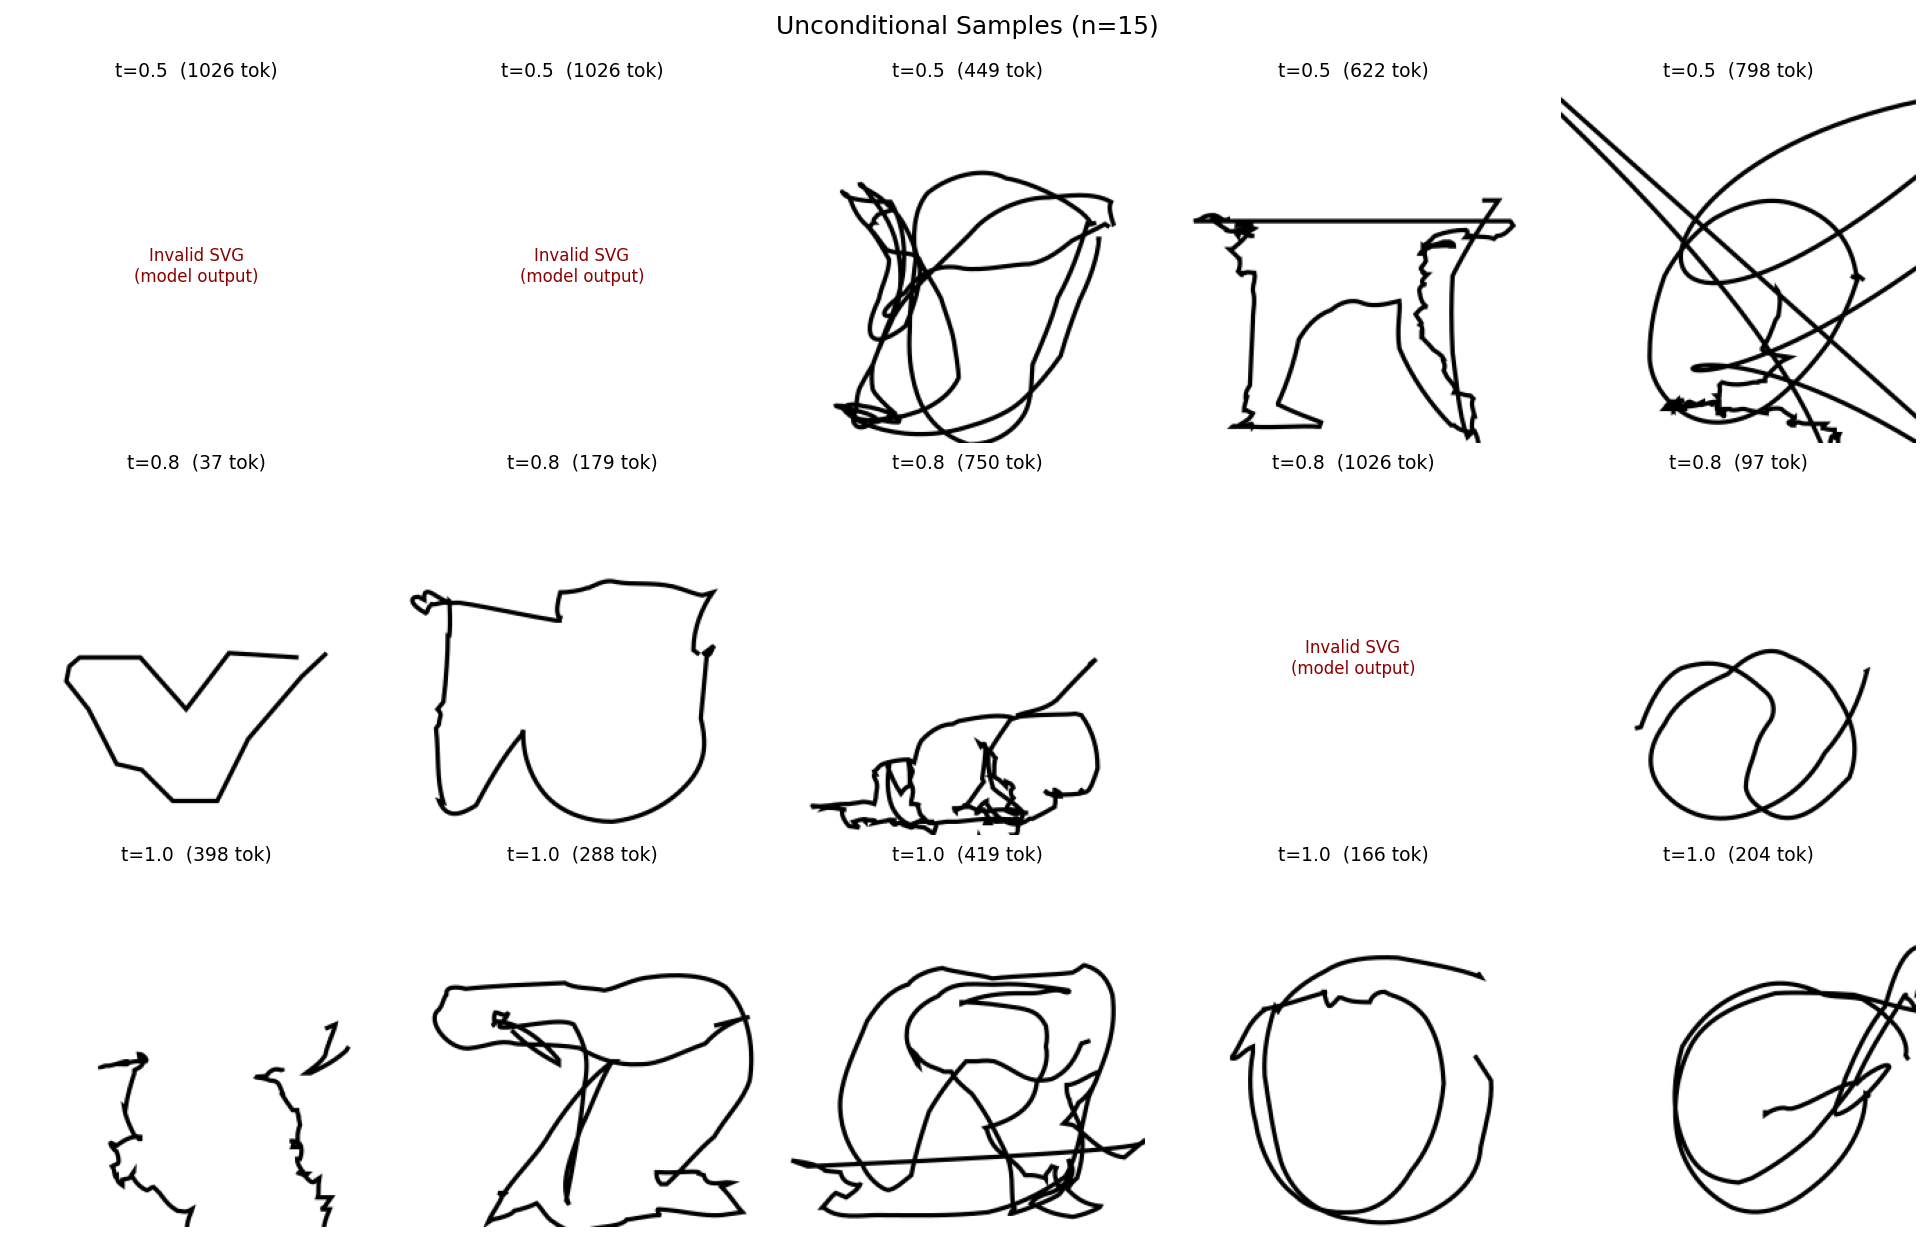


=== samples_temperature_comparison.png ===


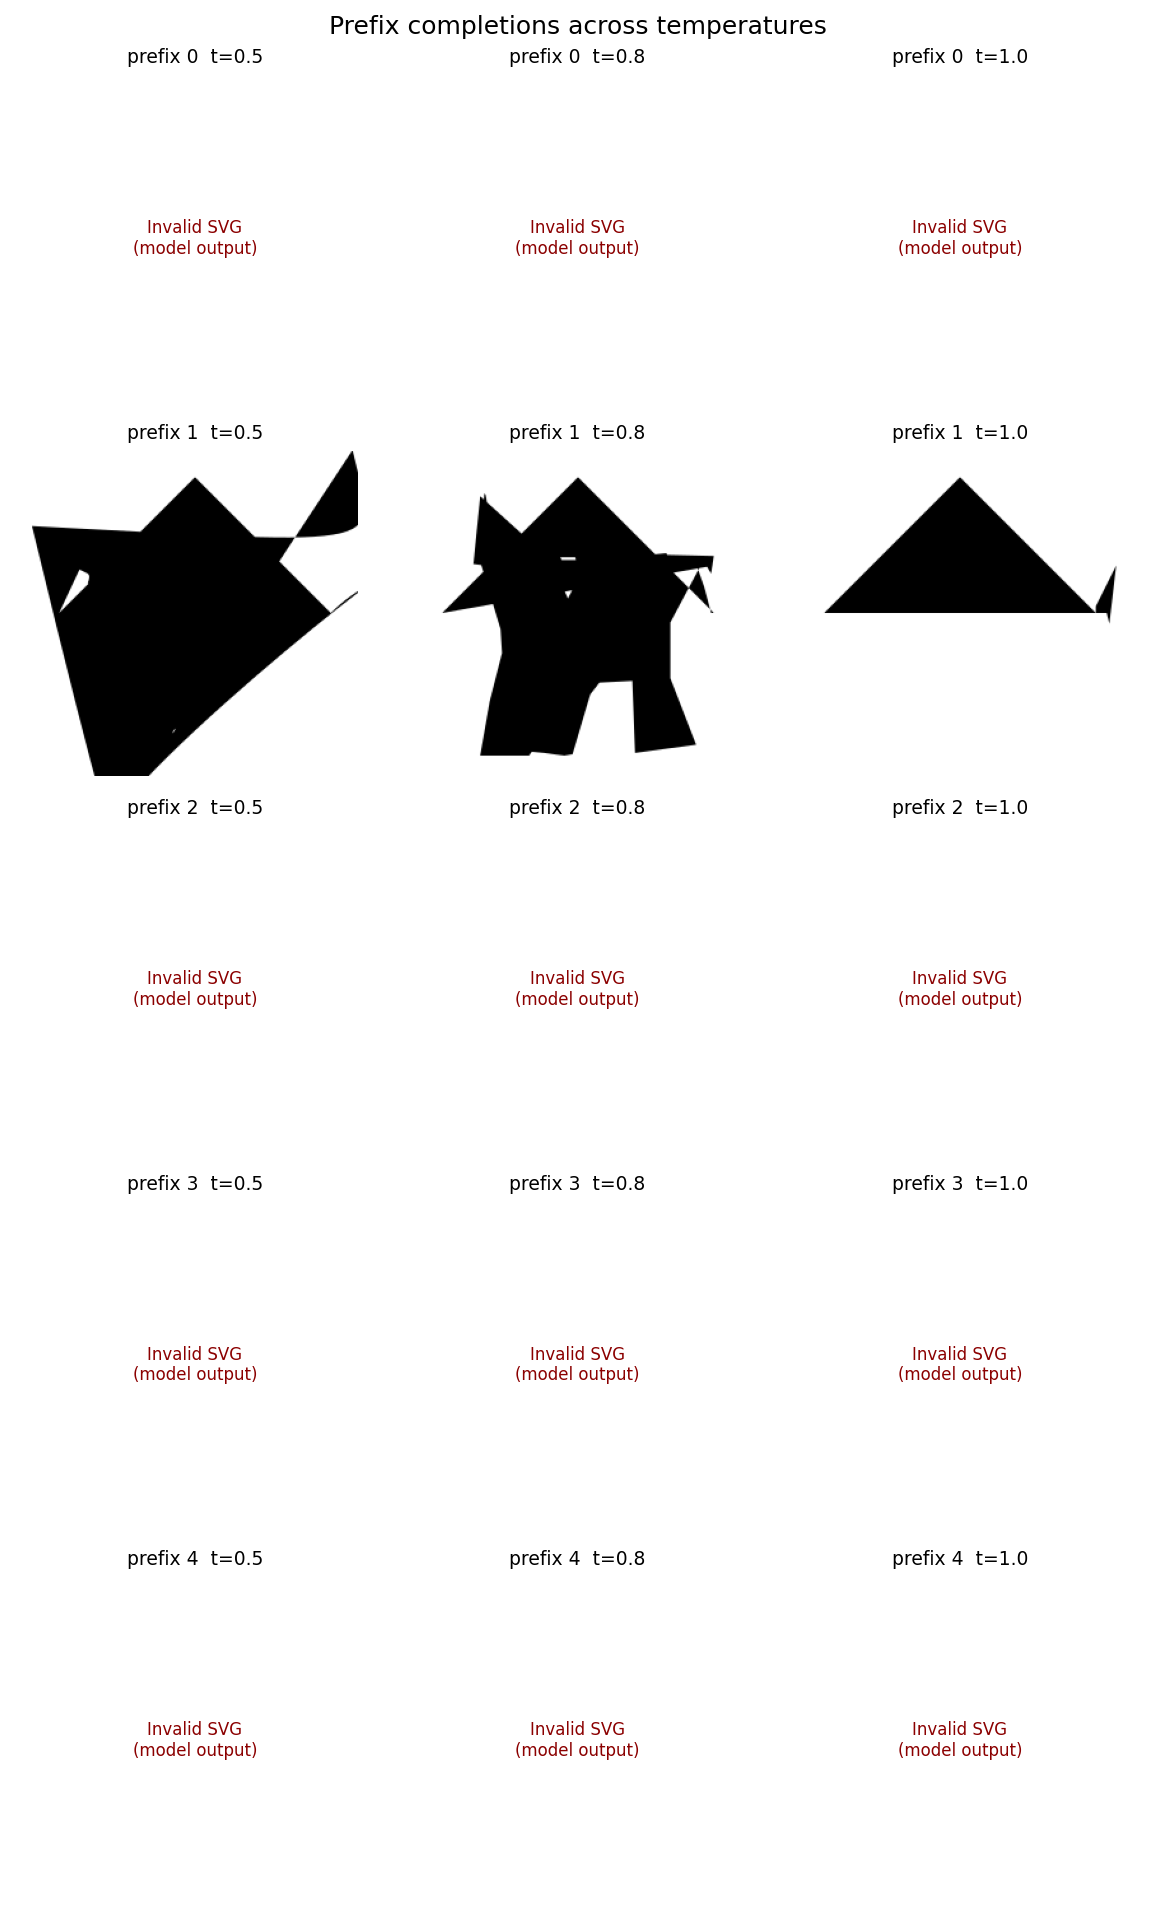


=== samples_prefix_completion.png ===


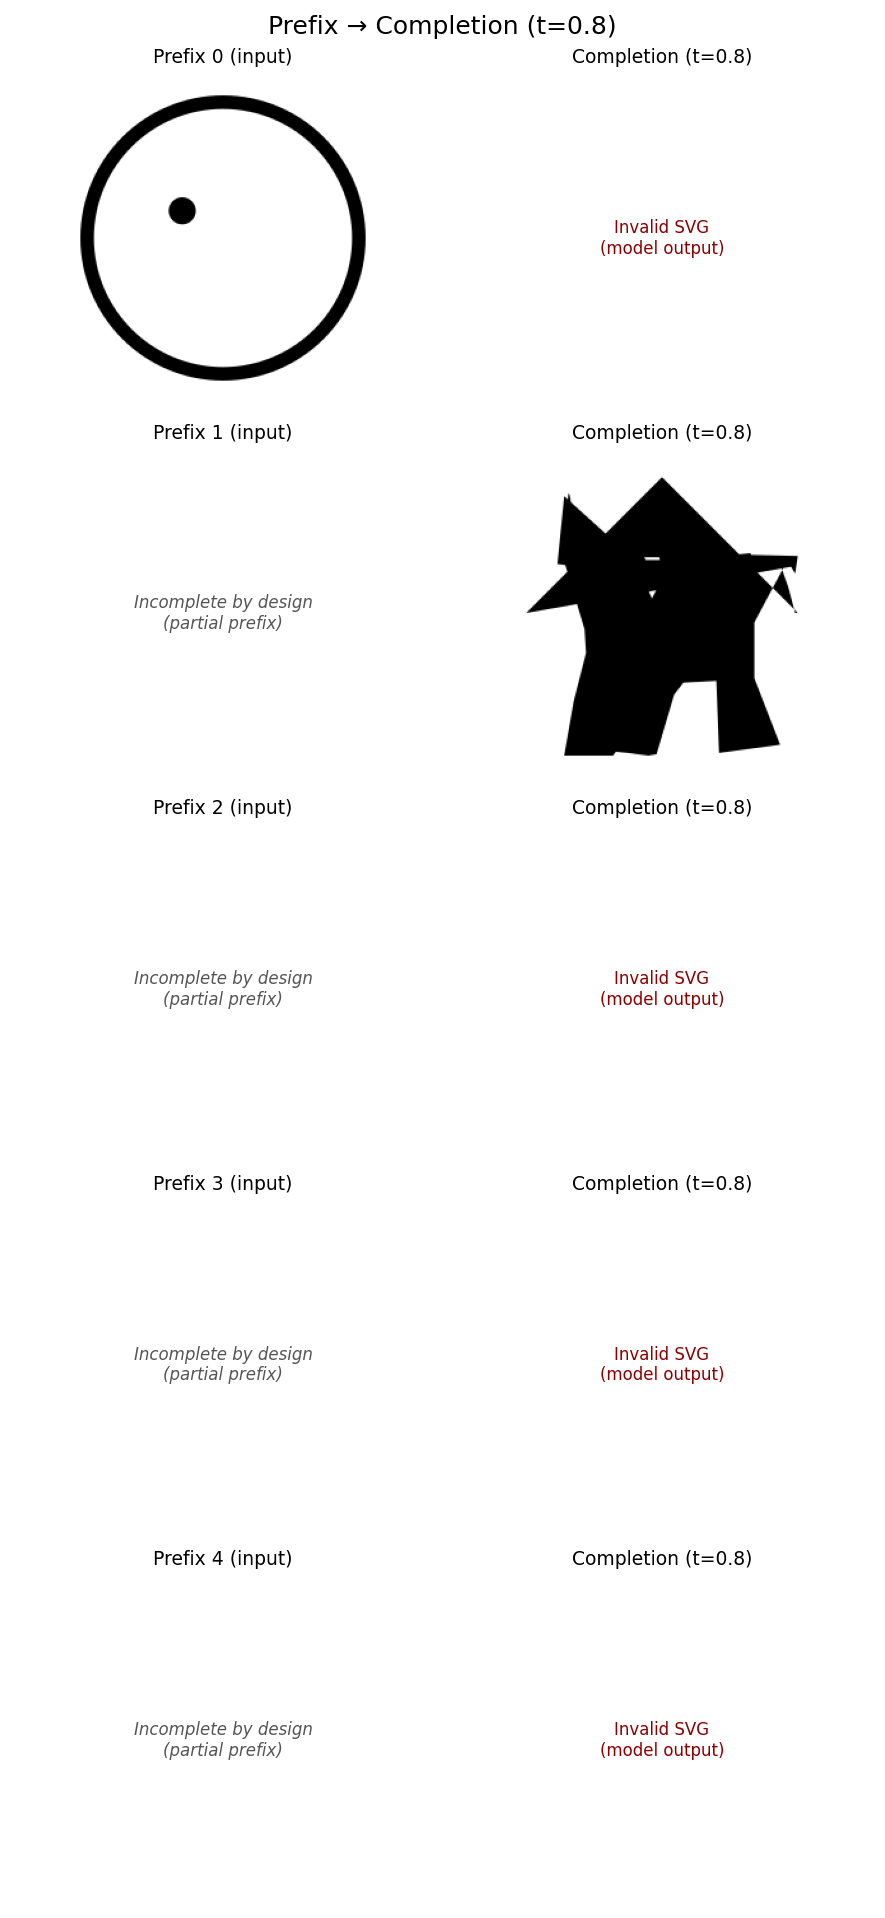

In [7]:
from IPython.display import Image, display
import os

for fname in ['samples_unconditional_grid.png',
              'samples_temperature_comparison.png',
              'samples_prefix_completion.png']:
    p = os.path.join('outputs/plots/1epoch', fname)
    print(f'\n=== {fname} ===')
    if os.path.exists(p):
        display(Image(filename=p))
    else:
        print(f'  MISSING: {p}')

In [ ]:
import json
from pathlib import Path

REPO = Path("/content/svg-scaling-laws")

with open(REPO / "outputs/logs/evaluation_metrics_1epoch.json") as f:
    m1 = json.load(f)

print("1-epoch evaluation summary")
print(f"  Unconditional render rate: {m1['unconditional']['rates']['svg_renderable_rate']*100:.1f}%")
print(f"  Prefix render rate:        {m1['prefix']['rates']['svg_renderable_rate']*100:.1f}%")
print(f"  Combined render rate:      {m1['combined']['rates']['svg_renderable_rate']*100:.1f}%")
if "perplexity" in m1:
    print(f"  Test perplexity:           {m1['perplexity']['perplexity']:.2f}")
    print(f"  Mean CE:                   {m1['perplexity']['mean_cross_entropy']:.4f}")

# Token-length stats from the manifest — key evidence for the truncation argument.
with open(REPO / "outputs/samples_1epoch/manifest.json") as f:
    man = json.load(f)

uncond_lens = [s["n_tokens"] for s in man["unconditional"]]
prefix_lens = [s["n_tokens"] for s in man["prefix"]]
hit_cap_uncond = sum(1 for n in uncond_lens if n >= 1025)
hit_cap_prefix = sum(1 for n in prefix_lens if n >= 1025)
print(f"\n  Unconditional length range: {min(uncond_lens)}–{max(uncond_lens)} tokens")
print(f"  Prefix length range:        {min(prefix_lens)}–{max(prefix_lens)} tokens")
print(f"  Hit 1024-token cap:         uncond {hit_cap_uncond}/15, prefix {hit_cap_prefix}/15")


1-epoch evaluation summary
  Unconditional render rate: 80.0%
  Prefix render rate:        20.0%
  Combined render rate:      50.0%
  Test perplexity:           22.31
  Mean CE:                   3.1048

  Unconditional length range: 37–1026 tokens
  Prefix length range:        23–1082 tokens
  Hit 1024-token cap:         uncond 3/15, prefix 3/15


In [ ]:
import os

EXT_CKPT = 'outputs/checkpoints/xl_extended/best.pt'

if os.path.exists(EXT_CKPT):
    sz = os.path.getsize(EXT_CKPT) / 1e6
    print(f'Extended checkpoint already exists ({sz:.0f} MB) — skipping training.')
else:
    print('Training extended model (3 extra epochs) ...')
    !python scripts/13_extend_xl.py \
        --source_checkpoint outputs/checkpoints/xl/best.pt \
        --extra_epochs 3 \
        --lr 3e-4 \
        --grad_accum 4

print(f'xl_extended/best.pt exists: {os.path.exists(EXT_CKPT)}')
if os.path.exists(EXT_CKPT):
    print(f'  size: {os.path.getsize(EXT_CKPT)/1e6:.0f} MB')


Extended checkpoint already exists (1118 MB) — skipping training.
xl_extended/best.pt exists: True
  size: 1118 MB


---
## Extended XL (4 Epochs): Generate, Evaluate, Plot
Samples from the extended checkpoint. Same architecture, 3 additional epochs of training.
Runs `scripts/10_generate_samples.py`. Writes:
- `outputs/samples/unconditional/uncond_t{T}_{i}.svg` (15 samples = 3 temps × 5)
- `outputs/samples/prefix/prefix{i}_t{T}.svg` (15 samples = 5 prefixes × 3 temps)
- `outputs/samples/manifest.json`

In [ ]:
!python scripts/10_generate_samples.py \
    --checkpoint outputs/checkpoints/xl_extended/best.pt \
    --out_dir outputs/samples_extended


Device: cuda
Loaded checkpoint: /content/svg-scaling-laws/outputs/checkpoints/xl_extended/best.pt
  Non-emb params: 85,056,000
  Step:           5800
  Best val loss:  2.2427

=== Unconditional generation (5 per temperature) ===
  [1/15] t=0.5  tokens= 111  uncond_t0.5_00.svg
  [2/15] t=0.5  tokens= 237  uncond_t0.5_01.svg
  [3/15] t=0.5  tokens=  62  uncond_t0.5_02.svg
  [4/15] t=0.5  tokens=1026  uncond_t0.5_03.svg
  [5/15] t=0.5  tokens= 107  uncond_t0.5_04.svg
  [6/15] t=0.8  tokens=1026  uncond_t0.8_00.svg
  [7/15] t=0.8  tokens= 446  uncond_t0.8_01.svg
  [8/15] t=0.8  tokens=1026  uncond_t0.8_02.svg
  [9/15] t=0.8  tokens= 164  uncond_t0.8_03.svg
  [10/15] t=0.8  tokens=1026  uncond_t0.8_04.svg
  [11/15] t=1.0  tokens= 480  uncond_t1.0_00.svg
  [12/15] t=1.0  tokens= 109  uncond_t1.0_01.svg
  [13/15] t=1.0  tokens=  93  uncond_t1.0_02.svg
  [14/15] t=1.0  tokens= 106  uncond_t1.0_03.svg
  [15/15] t=1.0  tokens= 182  uncond_t1.0_04.svg

=== Prefix-conditioned generation (5 prefixe

---
## Evaluate Samples + Test Perplexity
Runs `scripts/11_evaluate_samples.py`. Writes:
- `outputs/samples/rendered/{unconditional,prefix}/*.png` for every renderable sample
- `outputs/logs/evaluation_metrics.json`

In [ ]:
# Evaluate extended samples; metrics → evaluation_metrics_extended.json.
!cd /content/svg-scaling-laws && python scripts/11_evaluate_samples.py \
    --checkpoint outputs/checkpoints/xl_extended/best.pt \
    --samples_dir outputs/samples_extended \
    --rendered_dir outputs/samples_extended/rendered \
    --metrics_path outputs/logs/evaluation_metrics_extended.json


Device: cuda

=== Unconditional samples ===
  {'total': 15, 'xml_valid': 11, 'has_svg_root': 11, 'tags_closed': 11, 'svg_renderable': 11}
  xml_valid_rate: 73.3%
  has_svg_root_rate: 73.3%
  tags_closed_rate: 73.3%
  svg_renderable_rate: 73.3%

=== Prefix-conditioned samples ===
  {'total': 15, 'xml_valid': 1, 'has_svg_root': 1, 'tags_closed': 1, 'svg_renderable': 1}
  xml_valid_rate: 6.7%
  has_svg_root_rate: 6.7%
  tags_closed_rate: 6.7%
  svg_renderable_rate: 6.7%

=== Combined ===
  xml_valid_rate: 40.0%
  has_svg_root_rate: 40.0%
  tags_closed_rate: 40.0%
  svg_renderable_rate: 40.0%

=== Test-set perplexity ===
  Checkpoint: /content/svg-scaling-laws/outputs/checkpoints/xl_extended/best.pt
  Test bin:   /content/svg-scaling-laws/outputs/data/binary/test.bin
  Test tokens: 1,341,361  |  windows: 1309 × seq_len 1024
  Mean CE: 2.2308  |  Perplexity: 9.31

Metrics saved to /content/svg-scaling-laws/outputs/logs/evaluation_metrics_extended.json


---
## Plot Sample Figures
Runs `scripts/12_plot_samples.py`. Writes:
- `outputs/plots/samples_unconditional_grid.png`
- `outputs/plots/samples_temperature_comparison.png`
- `outputs/plots/samples_prefix_completion.png`

In [ ]:
!python scripts/12_plot_samples.py \
    --samples_dir outputs/samples_extended \
    --rendered_dir outputs/samples_extended/rendered \
    --plots_dir    outputs/plots/extended \
    --rows 3


  Unconditional grid: 11/15 PNGs found at /content/svg-scaling-laws/outputs/samples_extended/rendered/unconditional
Saved: /content/svg-scaling-laws/outputs/plots/extended/samples_unconditional_grid.png
Saved: /content/svg-scaling-laws/outputs/plots/extended/samples_temperature_comparison.png
Saved: /content/svg-scaling-laws/outputs/plots/extended/samples_prefix_completion.png

All Phase 4 plots generated.


---
##  Display Plots Inline


=== samples_unconditional_grid.png ===


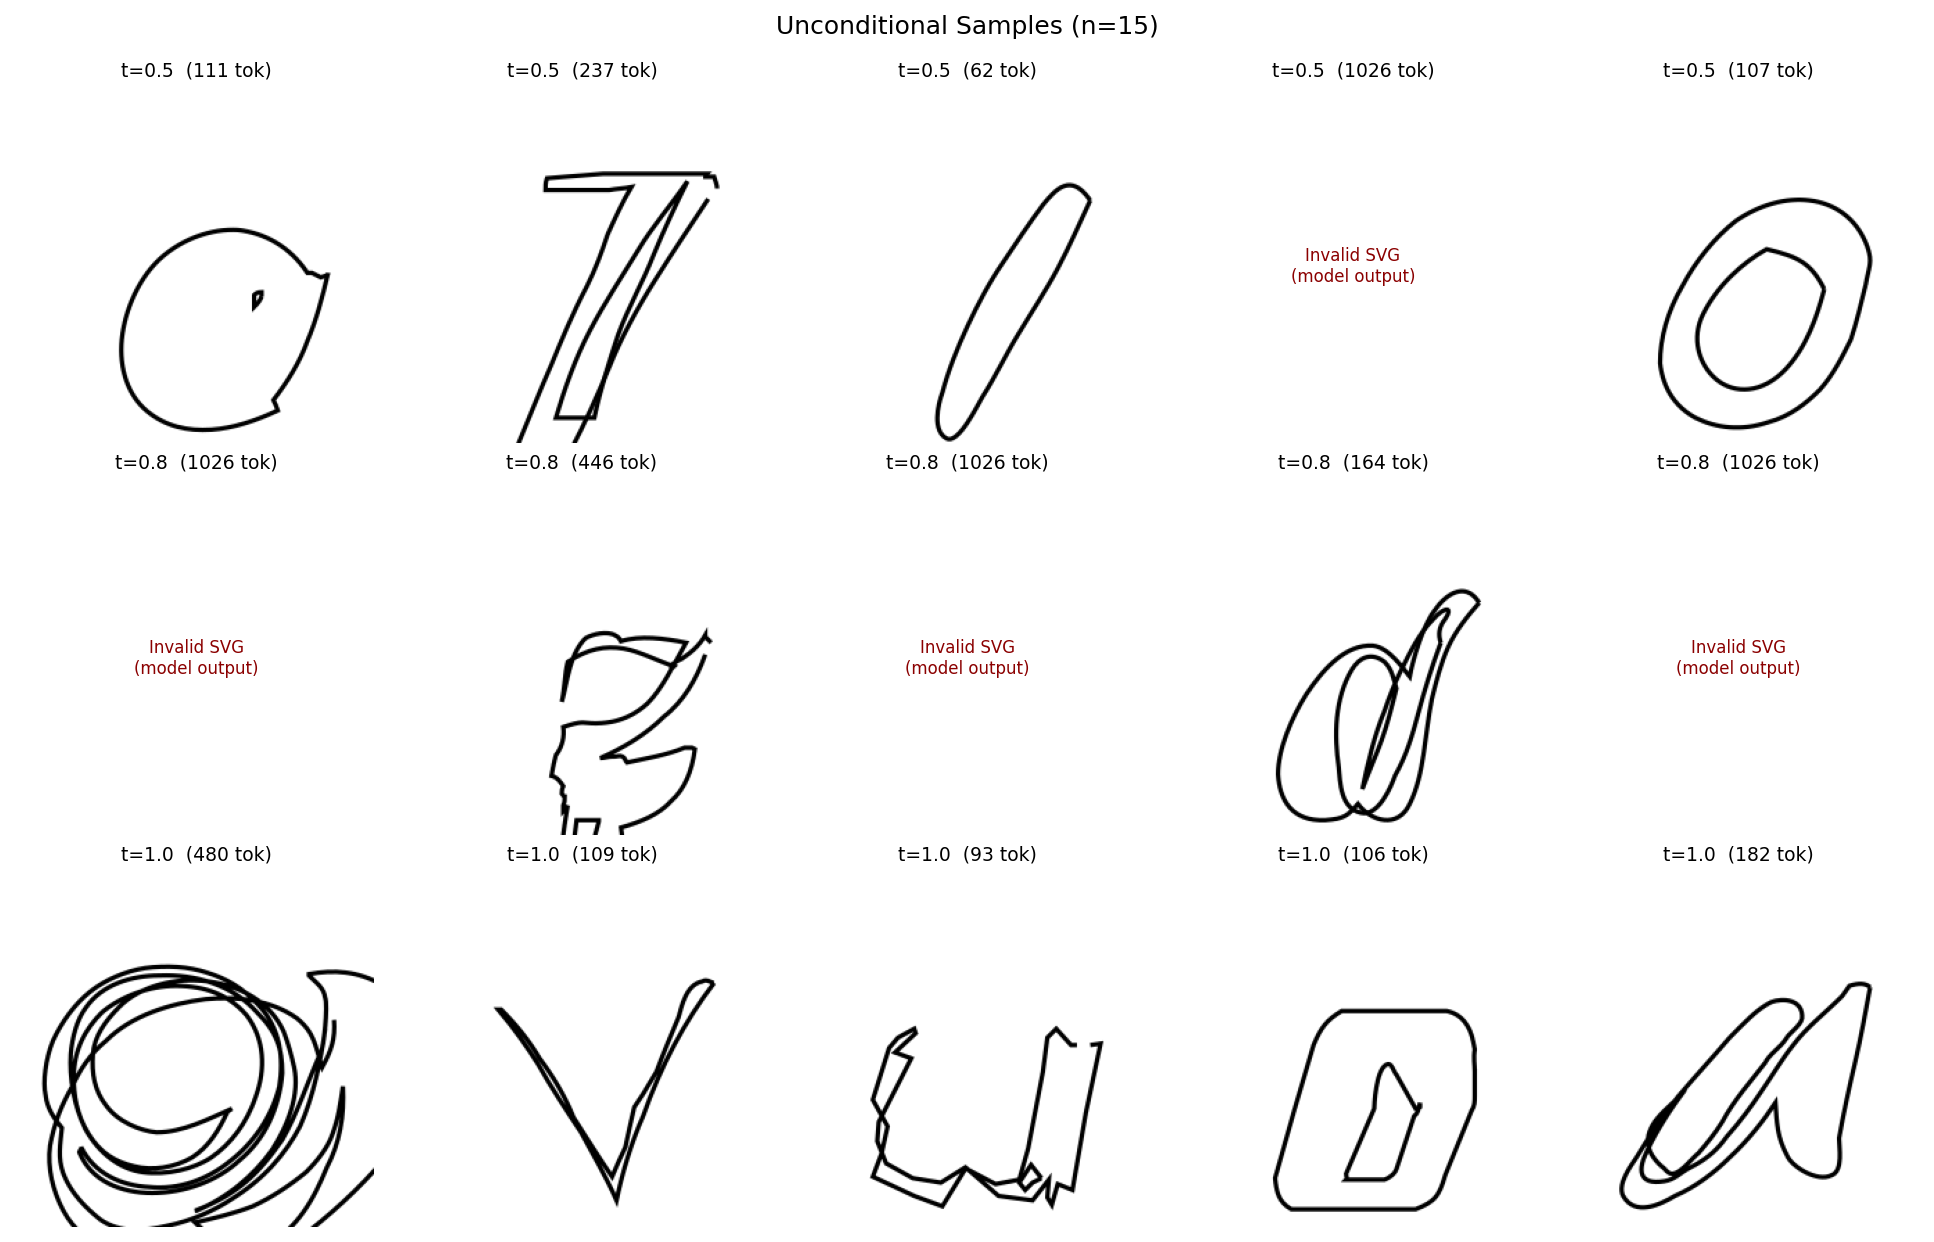


=== samples_temperature_comparison.png ===


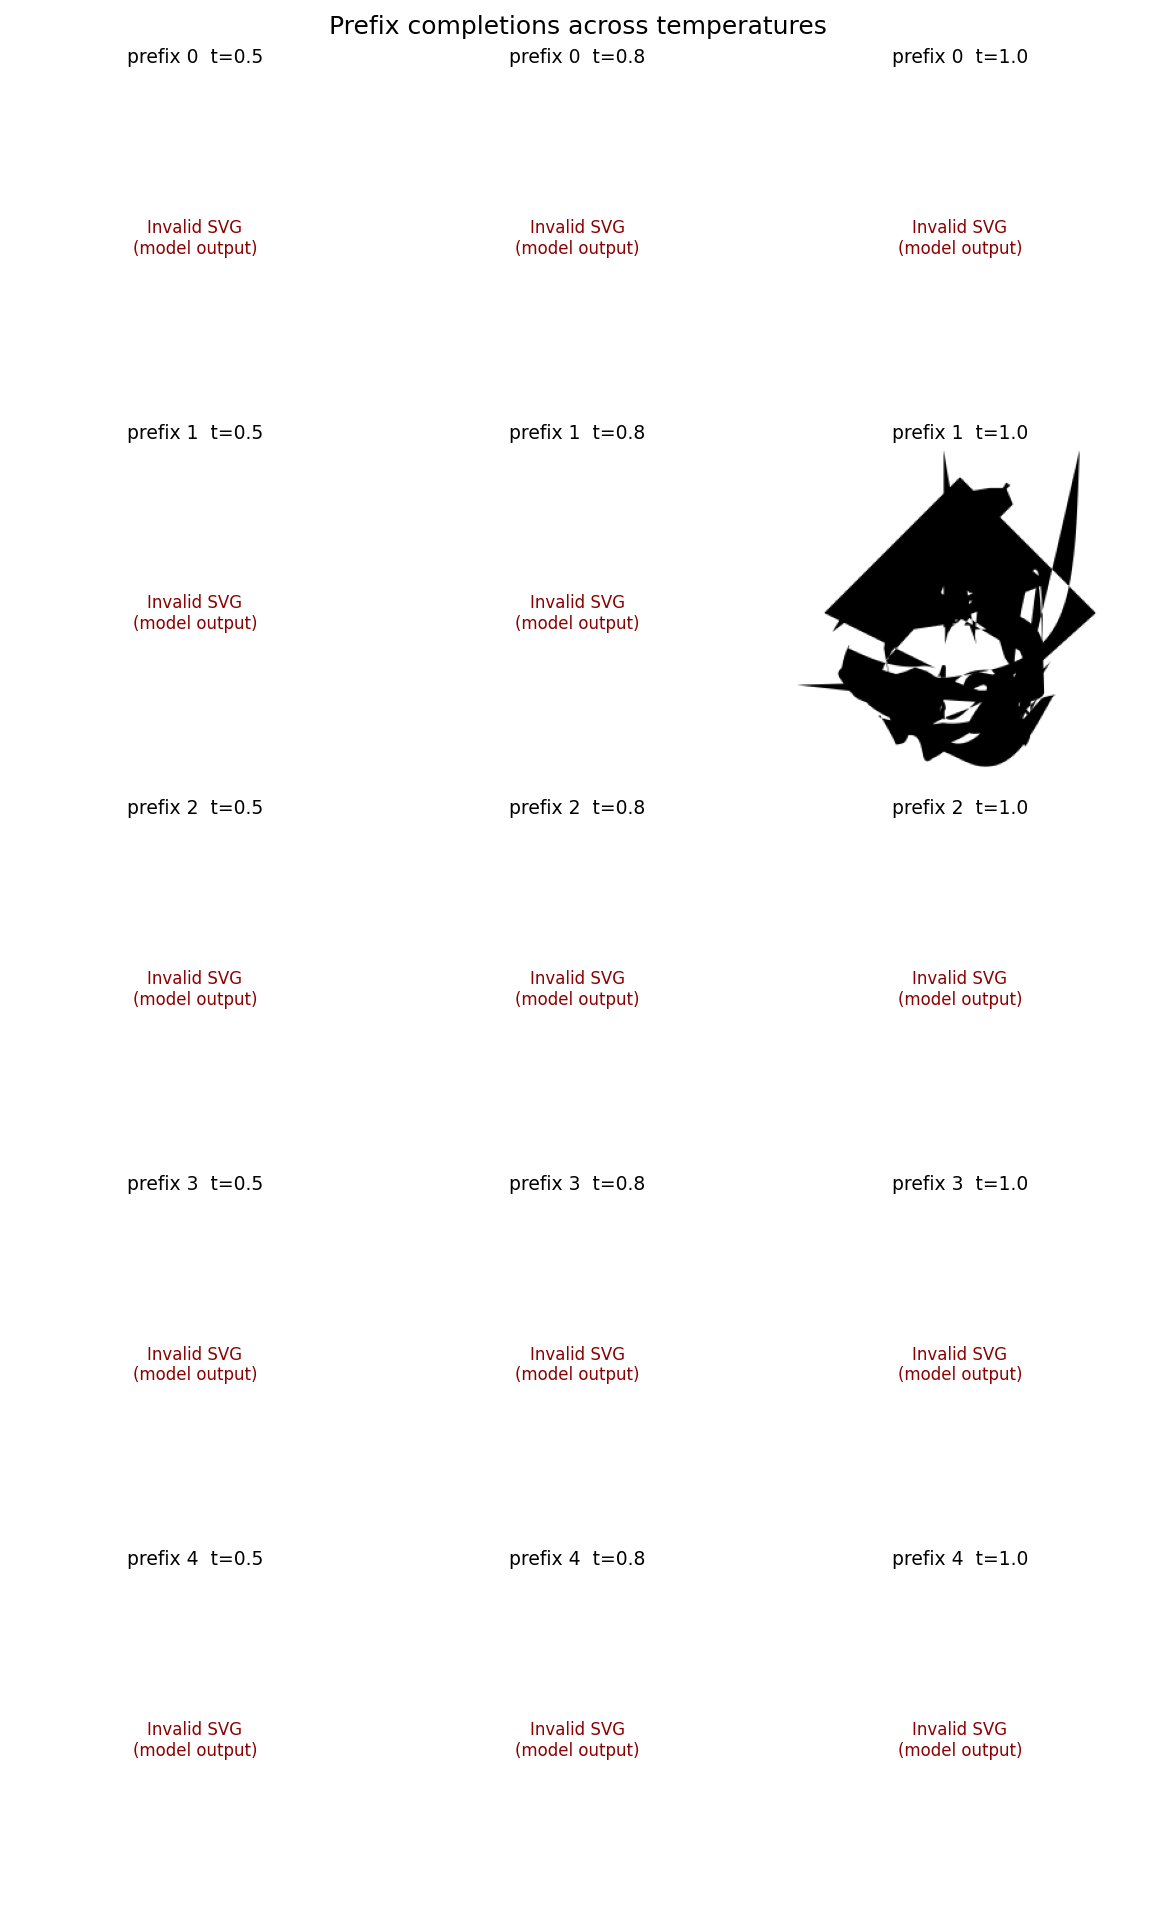


=== samples_prefix_completion.png ===


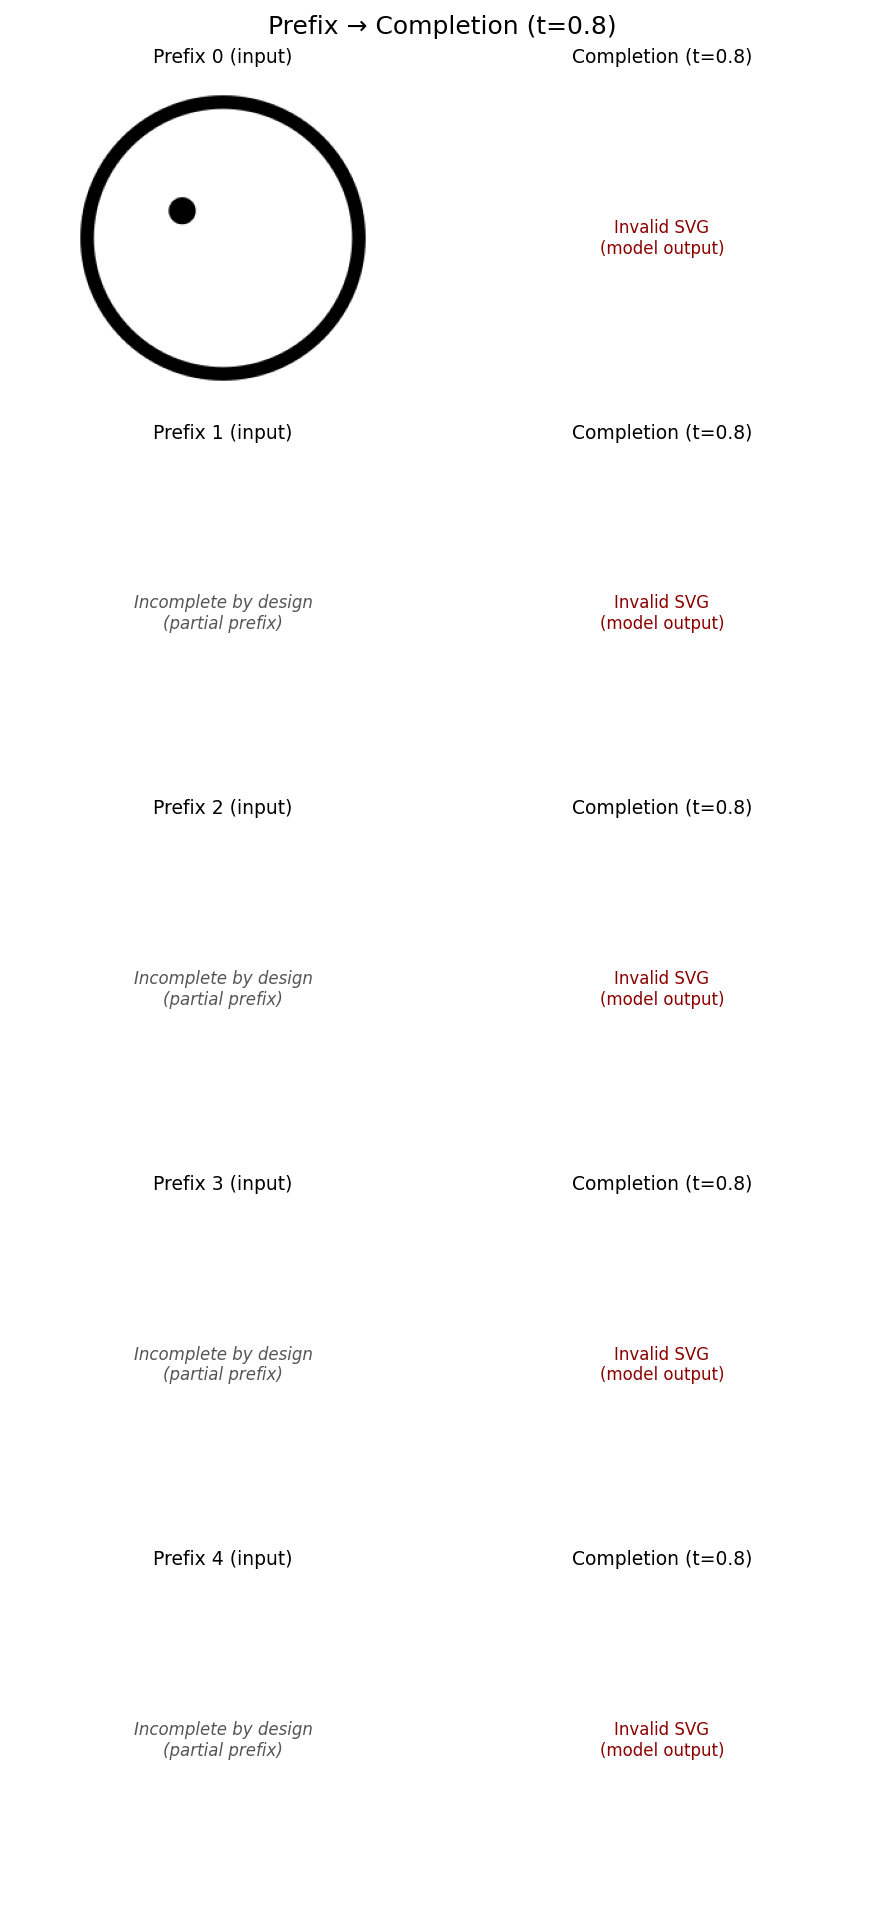

In [6]:
from IPython.display import Image, display
import os

for fname in ['samples_unconditional_grid.png',
              'samples_temperature_comparison.png',
              'samples_prefix_completion.png']:
    p = os.path.join('outputs/plots/extended', fname)
    print(f'\n=== {fname} ===')
    if os.path.exists(p):
        display(Image(filename=p))
    else:
        print(f'  MISSING: {p}')

---
## Cell 9: Print Evaluation Metrics Table

In [ ]:
import json
from pathlib import Path

REPO = Path("/content/svg-scaling-laws")

with open(REPO / "outputs/logs/evaluation_metrics_1epoch.json") as f:
    m1 = json.load(f)
with open(REPO / "outputs/logs/evaluation_metrics_extended.json") as f:
    me = json.load(f)
with open(REPO / "outputs/samples_1epoch/manifest.json") as f:
    man1 = json.load(f)
with open(REPO / "outputs/samples_extended/manifest.json") as f:
    man_e = json.load(f)

def cap_hits(manifest, key, cap=1025):
    lens = [s["n_tokens"] for s in manifest[key]]
    return sum(1 for n in lens if n >= cap), len(lens), lens

u1_hit, u1_n, u1_lens = cap_hits(man1,  "unconditional")
ue_hit, ue_n, ue_lens = cap_hits(man_e, "unconditional")
p1_hit, p1_n, _       = cap_hits(man1,  "prefix")
pe_hit, pe_n, _       = cap_hits(man_e, "prefix")

def pct(d, section, k="svg_renderable_rate"):
    return f"{d[section]['rates'][k]*100:.1f}%"

ppl1 = m1.get("perplexity", {}).get("perplexity", float("nan"))
ppl_e = me.get("perplexity", {}).get("perplexity", float("nan"))
ce1   = m1.get("perplexity", {}).get("mean_cross_entropy", float("nan"))
ce_e  = me.get("perplexity", {}).get("mean_cross_entropy", float("nan"))

print("=" * 70)
print(f"{'Metric':<35} {'1-epoch':>15} {'Extended':>15}")
print("=" * 70)
print(f"{'Test perplexity':<35} {ppl1:>15.2f} {ppl_e:>15.2f}")
print(f"{'Mean cross-entropy':<35} {ce1:>15.4f} {ce_e:>15.4f}")
print(f"{'Unconditional XML valid':<35} {pct(m1,'unconditional','xml_valid_rate'):>15} {pct(me,'unconditional','xml_valid_rate'):>15}")
print(f"{'Unconditional render rate':<35} {pct(m1,'unconditional'):>15} {pct(me,'unconditional'):>15}")
print(f"{'Prefix render rate':<35} {pct(m1,'prefix'):>15} {pct(me,'prefix'):>15}")
print(f"{'Combined render rate':<35} {pct(m1,'combined'):>15} {pct(me,'combined'):>15}")
print("-" * 70)
print(f"{'Unconditional hit 1024-tok cap':<35} {f'{u1_hit}/{u1_n}':>15} {f'{ue_hit}/{ue_n}':>15}")
print(f"{'Prefix hit 1024-tok cap':<35} {f'{p1_hit}/{p1_n}':>15} {f'{pe_hit}/{pe_n}':>15}")
print(f"{'Mean uncond length (tokens)':<35} {sum(u1_lens)/len(u1_lens):>15.0f} {sum(ue_lens)/len(ue_lens):>15.0f}")
print(f"{'Median uncond length (tokens)':<35} {sorted(u1_lens)[len(u1_lens)//2]:>15} {sorted(ue_lens)[len(ue_lens)//2]:>15}")
print("=" * 70)


Metric                                      1-epoch        Extended
Test perplexity                               22.31            9.31
Mean cross-entropy                           3.1048          2.2308
Unconditional XML valid                       80.0%           73.3%
Unconditional render rate                     80.0%           73.3%
Prefix render rate                            20.0%            6.7%
Combined render rate                          50.0%           40.0%
----------------------------------------------------------------------
Unconditional hit 1024-tok cap                 3/15            4/15
Prefix hit 1024-tok cap                        3/15           12/15
Mean uncond length (tokens)                     499             413
Median uncond length (tokens)                   419             182


---
## Final Results

Reads directly from saved JSON files. No generation is re-run. All numbers here are authoritative.


In [ ]:
import json, os
from pathlib import Path

REPO = Path("/content/svg-scaling-laws")
LOG  = REPO / "outputs/logs"

# ── Load metrics ──────────────────────────────────────────────────────────────
def load(name):
    p = LOG / name
    if not p.exists():
        return None
    with open(p) as f:
        return json.load(f)

def load_manifest(subdir):
    p = REPO / "outputs" / subdir / "manifest.json"
    if not p.exists():
        return None
    with open(p) as f:
        return json.load(f)

m1  = load("evaluation_metrics_1epoch.json")
me  = load("evaluation_metrics_extended.json")
mn1 = load_manifest("samples_1epoch")
mne = load_manifest("samples_extended")

# ── Configuration provenance ───────────────────────────────────────────────────
print("=" * 70)
print("CONFIGURATION PROVENANCE")
print("=" * 70)

for label, metrics, manifest in [
    ("1-epoch baseline",          m1,  mn1),
    ("Extended (3 extra epochs)", me,  mne),
]:
    print(f"\n{label}")
    if manifest:
        print(f"  Checkpoint:     {manifest.get('checkpoint', 'N/A')}")
        print(f"  max_new_tokens: {manifest.get('max_new_tokens', 'N/A')}")
        print(f"  top_k:          {manifest.get('top_k', 'N/A')}")
        print(f"  top_p:          {manifest.get('top_p', 'N/A')}")
        print(f"  temperatures:   {manifest.get('temperatures', 'N/A')}")
        seeds = ([s["seed"] for s in manifest.get("unconditional", [])] +
                 [s["seed"] for s in manifest.get("prefix", [])])
        if seeds:
            print(f"  Seeds (uncond): {[s['seed'] for s in manifest.get('unconditional', [])]}")
            print(f"  Seeds (prefix): {[s['seed'] for s in manifest.get('prefix', [])]}")
    else:
        print("  manifest.json: MISSING")
    if metrics is None:
        print("  metrics JSON:   MISSING")

# ── Token-length stats from manifests ─────────────────────────────────────────
def cap_stats(manifest, key, cap=1025):
    if manifest is None:
        return "N/A", "N/A", "N/A", "N/A"
    lens = [s["n_tokens"] for s in manifest.get(key, [])]
    if not lens:
        return "N/A", "N/A", "N/A", "N/A"
    n_hit = sum(1 for n in lens if n >= cap)
    return (f"{n_hit}/{len(lens)}",
            f"{min(lens)}–{max(lens)}",
            f"{sum(lens)/len(lens):.0f}",
            f"{sorted(lens)[len(lens)//2]}")

u1_cap, u1_range, u1_mean, u1_med = cap_stats(mn1, "unconditional")
ue_cap, ue_range, ue_mean, ue_med = cap_stats(mne, "unconditional")
p1_cap, p1_range, p1_mean, p1_med = cap_stats(mn1, "prefix")
pe_cap, pe_range, pe_mean, pe_med = cap_stats(mne, "prefix")

# ── Rate helper ───────────────────────────────────────────────────────────────
def pct(metrics, section, key="svg_renderable_rate"):
    if metrics is None:
        return "N/A"
    v = metrics.get(section, {}).get("rates", {}).get(key)
    return f"{v*100:.1f}%" if v is not None else "N/A"

def ppl_val(metrics, key):
    if metrics is None:
        return "N/A"
    v = metrics.get("perplexity", {}).get(key)
    return f"{v:.4f}" if v is not None else "N/A"

# ── Comparison table ───────────────────────────────────────────────────────────
print("\n")
print("=" * 70)
print("RESULTS COMPARISON")
print("=" * 70)
W = 35
print(f"{'Metric':<{W}} {'1-epoch':>15} {'Extended':>15}")
print("-" * 70)

rows = [
    ("Test perplexity",               ppl_val(m1,"perplexity"),         ppl_val(me,"perplexity")),
    ("Mean cross-entropy",            ppl_val(m1,"mean_cross_entropy"),  ppl_val(me,"mean_cross_entropy")),
    ("Unconditional render rate",     pct(m1,"unconditional"),           pct(me,"unconditional")),
    ("Prefix render rate",            pct(m1,"prefix"),                  pct(me,"prefix")),
    ("Combined render rate",          pct(m1,"combined"),                pct(me,"combined")),
    ("Unconditional XML valid",       pct(m1,"unconditional","xml_valid_rate"), pct(me,"unconditional","xml_valid_rate")),
    ("Prefix XML valid",              pct(m1,"prefix","xml_valid_rate"), pct(me,"prefix","xml_valid_rate")),
    ("─" * (W-1),                     "─" * 15,                         "─" * 15),
    ("Uncond hit 1024-tok cap",       u1_cap,                            ue_cap),
    ("Prefix hit 1024-tok cap",       p1_cap,                            pe_cap),
    ("Uncond token range",            u1_range,                          ue_range),
    ("Uncond mean length (tokens)",   u1_mean,                           ue_mean),
    ("Uncond median length (tokens)", u1_med,                            ue_med),
    ("Prefix token range",            p1_range,                          pe_range),
]

for label, v1, ve in rows:
    print(f"{label:<{W}} {v1:>15} {ve:>15}")

print("=" * 70)
print("\nSource files:")
for name in ["evaluation_metrics_1epoch.json", "evaluation_metrics_extended.json"]:
    p = LOG / name
    exists = "✓" if p.exists() else "MISSING"
    print(f"  {exists}  {p}")
for label, subdir in [("1-epoch", "samples_1epoch"), ("extended", "samples_extended")]:
    p = REPO / "outputs" / subdir / "manifest.json"
    exists = "✓" if p.exists() else "MISSING"
    print(f"  {exists}  {p}  ({label} manifest)")


CONFIGURATION PROVENANCE

1-epoch baseline
  Checkpoint:     outputs/checkpoints/xl/best.pt
  max_new_tokens: 1024
  top_k:          50
  top_p:          0.95
  temperatures:   [0.5, 0.8, 1.0]
  Seeds (uncond): [12345, 12346, 12347, 12348, 12349, 12350, 12351, 12352, 12353, 12354, 12355, 12356, 12357, 12358, 12359]
  Seeds (prefix): [13345, 13346, 13347, 13348, 13349, 13350, 13351, 13352, 13353, 13354, 13355, 13356, 13357, 13358, 13359]

Extended (3 extra epochs)
  Checkpoint:     outputs/checkpoints/xl_extended/best.pt
  max_new_tokens: 1024
  top_k:          50
  top_p:          0.95
  temperatures:   [0.5, 0.8, 1.0]
  Seeds (uncond): [12345, 12346, 12347, 12348, 12349, 12350, 12351, 12352, 12353, 12354, 12355, 12356, 12357, 12358, 12359]
  Seeds (prefix): [13345, 13346, 13347, 13348, 13349, 13350, 13351, 13352, 13353, 13354, 13355, 13356, 13357, 13358, 13359]


RESULTS COMPARISON
Metric                                      1-epoch        Extended
------------------------------------